---
## **Etapa 1:** *Importação, estruturação e limpeza*


In [42]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame, Series
import numpy as np
from numpy import ndarray, dtype, uint8, uint16, uint32, uint
from numpy.typing import DTypeLike
from abc import ABC
from enum import Enum, auto
# from google.colab import drive

import sklearn.svm as svm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
import seaborn as sns

**Dicionário de Metadados Posição-Extensão (`tables_indexes_sizes`)**

Mapeamos as coordenadas exatas de cada bloco de interesse através de tuplas `(índice_inicial, largura_do_bloco)`. Isso desacopla a extração de dados dos rótulos de texto e garante determinismo absoluto na separação dos blocos.


In [43]:
# 1. Conecta a VM do Google Colab ao armazenamento do Google Drive
# drive.mount('/content/drive')
# 2. Define o caminho absoluto exato da planilha de dados no Google Drive ou local
# file_path: str = '/content/drive/MyDrive/SUMMIT/LitDigestFull.xlsx'
file_path: str = 'LitDigestFull.xlsx'

# 3. Dicionário de metadados com anotação de tipos (dict[str, list[tuple[int, int]]]).
# A estrutura mapeia cada ano (aba da planilha) para uma lista de tuplas no formato (coluna_inicial, largura_do_bloco).
tables_indexes_sizes: dict[str, list[tuple[int, int]]] = {
    '1924': [
        (1, 1), # _electoral_votes
        (2, 8), # __candidates
        (13, 6), # __same_voters_1920
        (19, 1), # _total_per_state
        (22, 22), # _results
    ],
    '1928': [
        (1, 1), # _electoral_votes
        (2, 1), # __hoover
        (3, 6), # __hoover_voters_1924
        (10, 1), # __smith
        (11, 6), # __smith_voters_1924
        (20, 3), # __minor_candidates
        (23, 1), # __total_per_state
        (26, 19), # _results
    ],
    '1932': [
        (1, 1), # _electoral_votes
        (2, 1), # __hoover
        (3, 4), # __hoover_voters_1928
        (9, 1), # __roosevelt
        (10, 4), # __roosevelt_voters_1928
        (16, 7), # _minor_candidates
        (24, 1), # _total_per_state
        (28, 16), # _results
    ],
    '1936': [
        (1, 1), # _electoral_votes
        (2, 1), # __landon
        (3, 6), # __landon_voters_1932
        (10, 1), # __roosevelt
        (11, 6), # __roosevelt_voters_1932
        (18, 1), # __lemke
        (19, 6), # __lemke_voters_1932
        (26, 6), # __minor_candidates
        (32, 1), # _total_per_state
        (35, 19), # _results
    ]
}

discarded_lines: list[int] = [8, -2] # (Distrito de Columbia e Estados desconhecidos)

class StatesEnum(Enum):
    ALABAMA = auto(), 'AL'
    ARIZONA = auto(), 'AZ'
    ARKANSAS = auto(), 'AR'
    CALIFORNIA = auto(), 'CA'
    COLORADO = auto(), 'CO'
    CONNECTICUT = auto(), 'CT'
    DELAWARE = auto(), 'DE'
    FLORIDA = auto(), 'FL'
    GEORGIA = auto(), 'GA'
    IDAHO = auto(), 'ID'
    ILLINOIS = auto(), 'IL'
    INDIANA = auto(), 'IN'
    IOWA = auto(), 'IA'
    KANSAS = auto(), 'KS'
    KENTUCKY = auto(), 'KY'
    LOUISIANA = auto(), 'LA'
    MAINE = auto(), 'ME'
    MARYLAND = auto(), 'MD'
    MASSACHUSETTS = auto(), 'MA'
    MICHIGAN = auto(), 'MI'
    MINNESOTA = auto(), 'MN'
    MISSISSIPPI = auto(), 'MS'
    MISSOURI = auto(), 'MO'
    MONTANA = auto(), 'MT'
    NEBRASKA = auto(), 'NE'
    NEVADA = auto(), 'NV'
    NEW_HAMPSHIRE = auto(), 'NH'
    NEW_JERSEY = auto(), 'NJ'
    NEW_MEXICO = auto(), 'NM'
    NEW_YORK = auto(), 'NY'
    NORTH_CAROLINA = auto(), 'NC'
    NORTH_DAKOTA = auto(), 'ND'
    OHIO = auto(), 'OH'
    OKLAHOMA = auto(), 'OK'
    OREGON = auto(), 'OR'
    PENNSYLVANIA = auto(), 'PA'
    RHODE_ISLAND = auto(), 'RI'
    SOUTH_CAROLINA = auto(), 'SC'
    SOUTH_DAKOTA = auto(), 'SD'
    TENNESSEE = auto(), 'TN'
    TEXAS = auto(), 'TX'
    UTAH = auto(), 'UT'
    VERMONT = auto(), 'VT'
    VIRGINIA = auto(), 'VA'
    WASHINGTON = auto(), 'WA'
    WEST_VIRGINIA = auto(), 'WV'
    WISCONSIN = auto(), 'WI'
    WYOMING = auto(), 'WY'

def read_path(path: str) -> dict[str, pd.DataFrame]:
  # Lê a planilha Excel carrega só as abas necessárias em um único procedimento.
  #Trata erros de arquivo ausente ou com caminho incorreto.

    try:
  # Carrega em lote apenas as abas declaradas no dicionário de metadados
        excel_data = pd.read_excel(
            path,
            sheet_name=list(tables_indexes_sizes.keys()),
        )
    except (FileNotFoundError, ValueError, OSError) as error:
# Trata exceções exibindo mensagem amigável e retornando dicionário vazio
        print(f"\nArquivo inválido ou não encontrado: {path} ({error})\n")
        return {}
    else:
# Retorna o dicionário contendo os DataFrames brutos lidos
        return excel_data

**Fatiamento por Deslocamento Matricial (`sheet.take`)**

Utilizamos o método nativo do Pandas **`sheet.take(indices, axis='columns')`**, que opera diretamente sobre os ponteiros numéricos da matriz em C. A geração dos índices foi otimizada via NumPy utilizando o tipo **`uint8`** (inteiros sem sinal de 8 bits), garantindo alocação mínima de memória RAM.


In [44]:
# Gera um array NumPy de índices de colunas otimizado em memória usando o tipo uint8
# (inteiros sem sinal de 8 bits, alocando apenas 1 byte por número).
def create_columns_index(first: int, size: int) -> ndarray[tuple[int], dtype[uint8]]:

# Gera a sequência contínua de índices numéricos de colunas em baixo nível
    return np.array(range(size), dtype=uint8) + first

#Fatia a aba do Excel em sub-tabelas utilizando o método nativo em C 'take()' do Pandas.
#A extração posicional (axis='columns') garante alta performance e independência de nomes de colunas.

def tables_to_df(sheet: DataFrame, indexes_sizes: list[tuple[int, int]]) -> list[DataFrame]:

    return [
  # Aplica a extração de alta performance para cada tupla (índice, tamanho) da aba
        sheet.take(indices=create_columns_index(index, size), axis='columns') for index, size in indexes_sizes
    ]

**Ingestão Segura com Módulo `try-except-else` (`read_path`)**

Encapsulamos a leitura em uma função resiliente que trata exceções de arquivo (`FileNotFoundError`, `OSError`) e lê de uma só vez todas as abas necessárias via lista de chaves (`sheet_name`), retornando um dicionário limpo e validado.


In [45]:
# 1. Carrega todas as abas do Excel para a memória em um dicionário de DataFrames brutos
sheets: dict[str, DataFrame] = read_path(file_path)

# 2. Executa a dictionary comprehension para fatiar todas as sub-tabelas de cada ano em lote,
# gerando a estrutura final higienizada em 'raw_tables'

raw_tables: dict[str, list[DataFrame]] = {
    name: tables_to_df(sheets[name], indexes)
    for name, indexes in tables_indexes_sizes.items()
}

del tables_indexes_sizes, sheets

**Gerenciamento Ativo de Memória (`del`)**

Aplicamos a instrução `del tables_indexes_sizes, sheets` ao término da extração. Isso elimina os objetos temporários e força a desalocação no *Garbage Collector*, mantendo o ambiente limpo e focado apenas nos objetos estruturados finalizados (`raw_tables`).

In [46]:
class Votes(ABC):
    __slots__ = ('_results', '_electoral_votes', '_total_per_state')
# __slots__ limita a criação de atributos dinâmicos (__dict__), reduzindo drasticamente
    _results: DataFrame
# Declaração das anotações de tipo dos atributos protegidos da classe base
    _electoral_votes: ndarray[tuple[int], dtype[uint8]] # Array NumPy (uint8: 0 a 255) para os votos eleitorais
    _total_per_state: ndarray[tuple[int], dtype[uint32]] # Array NumPy (uint32) para a contagem total de respostas por estado

    def _clean_lines(self, df: DataFrame) -> DataFrame:
# Método interno de higienização: Remove linhas que estejam completamente vazias (NaN em todas as colunas).
        return df.dropna(axis='index', how='all')

    def _series_to_nparray(self, df: DataFrame, dtype: DTypeLike = uint16) -> ndarray[tuple[int], dtype[uint]]:
# Converte uma coluna de DataFrame em um ndarray NumPy tipado, descartando cabeçalhos e a linha final de total.
        df = self._clean_lines(df)
# Higieniza o DataFrame removendo linhas totalmente nulas
        return np.asarray(df[df.columns[0]].to_numpy(), dtype)
# Seleciona a 1ª coluna, fatia a partir da linha de cabeçalho até a penúltima linha (exclui o total) e converte para array NumPy

    def _get_totals(self, df: DataFrame) -> ndarray[tuple[int], dtype[uint32]]:
# Método interno de higienização: Remove linhas que estejam completamente vazias (NaN em todas as colunas).
        return df.values[-1]

    def get_electoral_votes(self) -> ndarray[tuple[int], dtype[uint8]]:
# Getter público: Retorna a série de votos do Colégio Eleitoral por estado.
        return self._electoral_votes[:-1]

    def get_total_per_state(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna o total de respostas da pesquisa por estado (excluindo a linha final do somatório nacional).
        return self._total_per_state[:-1]

    def get_results(self) -> DataFrame:
# Getter público: Retorna a tabela de resultados das urnas por estado (excluindo a linha final de totalizador).
        return self._results[:-1]

    def get_total_results(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna apenas o vetor do somatório nacional dos resultados reais (última linha).
        return self._get_totals(self._results)

    def _set_header_from(self, df: DataFrame, line_index: int = 0) -> DataFrame:
        df.columns = df.values[line_index]
        return df.drop(index=line_index)

    def _discard_lines(self, source: DataFrame, indexes: list[int]) -> DataFrame:
        return source.drop(index=[source.index[index] for index in indexes])

    def _prepare_dataframe(self, df: DataFrame, header_index: int = -1, discard_indexes: list[int] = [], clean_lines: bool = True) -> DataFrame:
        if clean_lines: df = self._clean_lines(df)
        if header_index != -1: df = self._set_header_from(df, header_index)
        if not len(discarded_lines) == 0: df = self._discard_lines(df, discard_indexes)
        return df

    def _prepare_nparray(self, df: DataFrame, header_index: int = -1, discard_indexes: list[int] = [], clean_lines: bool = True, dtype: DTypeLike = uint32) -> ndarray[tuple[int], dtype[uint]]:
        return self._series_to_nparray(self._prepare_dataframe(df, header_index, discard_indexes, clean_lines), dtype)

---
## **Etapa 2:** *Modelagem*

**Abstração de Arquitetura e Otimização de RAM (`ABC` & `__slots__`)**

*Herança e Abstração (`class Votes(ABC)`):* Centraliza a estrutura comum das pesquisas (1924–1936) sob uma classe abstrata base, garantindo a padronização das interfaces e reuso de código (*DRY - Don't Repeat Yourself*).
*Gestão Estática de Memória (`__slots__`):* Desativa o dicionário dinâmico de atributos (`__dict__`) nas classes base e derivadas, forçando a alocação fixa na memória RAM para acelerar a execução ao manipular os conjuntos de dados estaduais.

In [47]:
class Votes1924(Votes):
# __slots__ específico para os atributos privados exclusivos da eleição de 1924
    __slots__ = ('__candidates', '__same_voters_1920')
    __candidates: DataFrame
    __same_voters_1920: DataFrame

    def __init__(self, electoral_votes: DataFrame, candidates: DataFrame, same_voters_1920: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Construtor da classe para o ano de 1924: Recebe as sub-tabelas fatiadas e inicializa os atributos tratados.
# Remove a última coluna da sub-tabela de candidatos (geralmente uma coluna duplicada de total)

        self.__candidates = self._prepare_dataframe(candidates, discard_indexes=discarded_lines)
# Atribui a sub-tabela do histórico do voto cruzado da eleição de 1920
        self.__same_voters_1920 = self._prepare_dataframe(same_voters_1920, discard_indexes=discarded_lines)
# Converte e armazena os votos eleitorais usando uint8 (economia de memória)
        self._electoral_votes = self._prepare_nparray(electoral_votes, discard_indexes=[discarded_lines[0]], dtype=uint16).astype(uint16)
# Atribui o DataFrame do total por estado
        self._total_per_state = self._prepare_nparray(total_per_state, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Atribui o DataFrame com os resultados reais de 1924 (Wikipedia)
        self._results = self._prepare_dataframe(results)

    def get_candidates(self) -> DataFrame:
 # Getter público: Retorna as intenções de voto dos candidatos de 1924 por estado (sem a linha de total).
        return self.__candidates[:-1]

    def get_total_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna o vetor com o somatório nacional de votos de cada candidato em 1924.
        return self._get_totals(self.__candidates)

    def get_same_voters_1920(self) -> DataFrame:
# Getter público: Retorna o histórico de como os eleitores de 1924 votaram em 1920 por estado (sem a linha de total).
        return self.__same_voters_1920[:-1]

    def get_total_same_voters_1920(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: Retorna o vetor com o somatório nacional do histórico de voto de 1920.
        return self._get_totals(self.__same_voters_1920)

**Tipagem Numérica, Tratamento de Totais e Encapsulamento (`uint`, `[:-1]` & `_/__`)**

*Tipagem Numérica Estrita (`uint8` e `uint32`):* Otimiza o uso de memória convertendo colunas para arrays NumPy **uint8** (1 byte) para votos eleitorais (máx. 255) e **uint32** para contagens absolutas de respostas.
*Isolamento de Totais (`[:-1]` e `_get_totals`):* Oculta a linha de somatório nacional nas chamadas estaduais (`[:-1]`), evitando duplicação de dados e distorções em modelos estatísticos ou de Machine Learning.
*Encapsulamento de Atributos (`_` e `__`):* Usa o prefixo protegido **_** para atributos herdados e o privado `__` (*Name Mangling*) para tabelas exclusivas do ano, garantindo o controle de acesso e a integridade dos dados.

In [48]:
# Classe derivada concreta referente ao ano eleitoral de 1928 (Hoover x Smith)
class Votes1928(Votes):
# __slots__ limita dinamicamente os atributos da classe aos declarados, reduzindo o consumo de memória RAM
    __slots__ = ('__hoover', '__hoover_voters_1924', '__smith', '__smith_voters_1924', '__minor_candidates')
    __hoover: ndarray[tuple[int], dtype[uint32]]
    __hoover_voters_1924: DataFrame
    __smith: ndarray[tuple[int], dtype[uint32]]
    __smith_voters_1924: DataFrame
    __minor_candidates: DataFrame

# Construtor da classe de 1928: recebe os DataFrames fatiados e os converte para estruturas otimizadas
    def __init__(self, electoral_votes: DataFrame, hoover: DataFrame, hoover_voters_1924: DataFrame, smith: DataFrame, smith_voters_1924: DataFrame, minor_candidates: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Converte a coluna de votos de Herbert Hoover em ndarray NumPy tipado (uint32)
        self.__hoover = self._prepare_nparray(hoover, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1924 dos eleitores de Hoover
        self.__hoover_voters_1924 = self._prepare_dataframe(hoover_voters_1924, header_index=0, discard_indexes=discarded_lines)
# Converte a coluna de votos de Alfred Smith em ndarray NumPy tipado (uint32)
        self.__smith = self._prepare_nparray(smith, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1924 dos eleitores de Smith
        self.__smith_voters_1924 = self._prepare_dataframe(smith_voters_1924, header_index=0, discard_indexes=discarded_lines)
# Armazena o DataFrame dos candidatos minoritários
        self.__minor_candidates = self._prepare_dataframe(minor_candidates, header_index=0, discard_indexes=discarded_lines)
# Converte os votos do Colégio Eleitoral em array NumPy tipado (uint8)
        self._electoral_votes = self._prepare_nparray(electoral_votes, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint16).astype(uint16)
# Converte os totais por estado em array NumPy tipado (uint32)
        self._total_per_state = self._prepare_nparray(total_per_state, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com os resultados reais das urnas de 1928
        self._results = self._prepare_dataframe(results)

    def get_hoover(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Hoover por estado (excluindo a linha final de totalizador)
        return self.__hoover[:-1]

    def get_total_hoover(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Hoover
        return self.__hoover[-1]

    def get_hoover_voters_1924(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1924 dos eleitores de Hoover por estado (sem totalizador)
        return self.__hoover_voters_1924[:-1]

    def get_total_hoover_voters_1924(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1924 dos eleitores de Hoover
        return self._get_totals(self.__hoover_voters_1924)

    def get_smith(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Smith por estado (excluindo a linha final de totalizador)
        return self.__smith[:-1]

    def get_total_smith(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Smith
        return self.__smith[-1]

    def get_smith_voters_1924(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1924 dos eleitores de Smith por estado (sem totalizador)
        return self.__smith_voters_1924[:-1]

    def get_total_smith_voters_1924(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1924 dos eleitores de Smith
        return self._get_totals(self.__smith_voters_1924)

    def get_minor_candidates(self) -> DataFrame:
# Getter público: retorna as votações dos candidatos minoritários por estado (sem totalizador)
        return self.__minor_candidates[:-1]

    def get_total_minor_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional dos candidatos minoritários
        return self._get_totals(self.__minor_candidates)

**Classe Derivada `Votes1928`**

Estende a classe abstrata base Votes para estruturar os dados da eleição entre Herbert Hoover (*Republicano*) e Alfred E. Smith (*Democrata*). *Estrutura de Voto Cruzado ($1924 \rightarrow 1928$):* Mapeia separadamente a votação dos candidatos principais (`__hoover`, `__smith`) e suas matrizes de fidelidade partidária (`__hoover_voters_1924`, `__smith_voters_1924`), essenciais para calibração estatística e pós-estratificação. *Otimização de RAM e Tipagem Vetorial (`__slots__` e `uint32`):* Converte colunas individuais em vetores ndarray de inteiros sem sinal de 32 bits (uint32), acelerando cálculos e restringindo a alocação dinâmica com `__slots__`.*Encapsulamento Privado e Interface Limpa:* Preserva a integridade dos atributos específicos por meio do prefixo `__` (Name Mangling) e expõe métodos getters purificados.

In [49]:
# Classe derivada concreta referente ao ano eleitoral de 1932 (Hoover x Roosevelt)
class Votes1932(Votes):
# __slots__ limita dinamicamente os atributos da classe aos declarados, reduzindo o consumo de memória RAM
    __slots__ = ('__hoover', '__hoover_voters_1928', '__roosevelt', '__roosevelt_voters_1928', '__minor_candidates')
    __hoover: ndarray[tuple[int], dtype[uint32]]
    __hoover_voters_1928: DataFrame
    __roosevelt: ndarray[tuple[int], dtype[uint32]]
    __roosevelt_voters_1928: DataFrame
    __minor_candidates: DataFrame

# Construtor da classe de 1932: recebe os DataFrames fatiados e os converte para estruturas otimizadas
    def __init__(self, electoral_votes: DataFrame, hoover: DataFrame, hoover_voters_1928: DataFrame, roosevelt: DataFrame, roosevelt_voters_1928: DataFrame, minor_candidates: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Converte a coluna de votos de Herbert Hoover em ndarray NumPy tipado (uint32)
        self.__hoover = self._prepare_nparray(hoover, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1928 dos eleitores de Hoover
        self.__hoover_voters_1928 = self._prepare_dataframe(hoover_voters_1928, header_index=0, discard_indexes=discarded_lines)
# Converte a coluna de votos de Franklin D. Roosevelt em ndarray NumPy tipado (uint32)
        self.__roosevelt = self._prepare_nparray(roosevelt, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1928 dos eleitores de Roosevelt
        self.__roosevelt_voters_1928 = self._prepare_dataframe(roosevelt_voters_1928, header_index=0, discard_indexes=discarded_lines)
# Armazena o DataFrame dos candidatos minoritários
        self.__minor_candidates = self._prepare_dataframe(minor_candidates, header_index=0, discard_indexes=discarded_lines)
# Converte os votos do Colégio Eleitoral em array NumPy tipado (uint8)
        self._electoral_votes = self._prepare_nparray(electoral_votes, header_index=0, discard_indexes=discarded_lines, dtype=uint16).astype(uint16)
# Converte os totais por estado em array NumPy tipado (uint32)
        self._total_per_state = self._prepare_nparray(total_per_state, header_index=0, discard_indexes=discarded_lines, dtype=uint32).astype(uint32)
# Armazena a sub-tabela com os resultados reais das urnas de 1932
        self._results = self._prepare_dataframe(results)

    def get_hoover(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Hoover por estado (excluindo a linha final de totalizador)
        return self.__hoover[:-1]

    def get_total_hoover(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Hoover
        return self.__hoover[-1]

    def get_hoover_voters_1928(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1928 dos eleitores de Hoover por estado (sem totalizador)
        return self.__hoover_voters_1928[:-1]

    def get_total_hoover_voters_1928(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1928 dos eleitores de Hoover
        return self._get_totals(self.__hoover_voters_1928)

    def get_roosevelt(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Roosevelt por estado (excluindo a linha final de totalizador)
        return self.__roosevelt[:-1]

    def get_total_roosevelt(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Roosevelt
        return self.__roosevelt[-1]

    def get_roosevelt_voters_1928(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1928 dos eleitores de Roosevelt por estado (sem totalizador)
        return self.__roosevelt_voters_1928[:-1]

    def get_total_roosevelt_voters_1928(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1928 dos eleitores de Roosevelt
        return self._get_totals(self.__roosevelt_voters_1928)

    def get_minor_candidates(self) -> DataFrame:
# Getter público: retorna as votações dos candidatos minoritários por estado (sem totalizador)
        return self.__minor_candidates[:-1]

    def get_total_minor_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional dos candidatos minoritários
        return self._get_totals(self.__minor_candidates)

**Classe Derivada `Votes1932`**

Herda da classe abstrata base Votes para estruturar os dados da eleição entre Herbert Hoover (*Republicano*) e Franklin D. Roosevelt (*Democrata*). *Estrutura de Voto Cruzado ($1928 \rightarrow 1932$):* Mapeia de forma independente os votos nos candidatos principais (`__hoover`, `__roosevelt`) e suas respectivas matrizes de transição partidária (`__hoover_voters_1928`, `__roosevelt_voters_1928`), fundamentais para a calibração estatística do desalinhamento eleitoral na Grande Depressão. Otimização de RAM e Tipagem Vetorial (`__slots__` e `uint32`): Converte as séries de votação em vetores ndarray de inteiros sem sinal de *32 bits* (**uint32**), acelerando cálculos matriciais e restringindo alocações dinâmicas de atributos via `__slots__`. *Encapsulamento Privado e Interface Limpa:* Protege a integridade dos atributos específicos por meio de `__` (Name Mangling) e expõe métodos getters devidamente fatiados.

In [50]:
# Classe derivada concreta referente ao ano eleitoral decisivo de 1936 (Landon x Roosevelt x Lemke)
class Votes1936(Votes):
# __slots__ limita dinamicamente os atributos da classe aos declarados, reduzindo o consumo de memória RAM
    __slots__ = ('__landon', '__landon_voters_1932', '__roosevelt', '__roosevelt_voters_1932', '__lemke', '__lemke_voters_1932', '__minor_candidates')
    __landon: ndarray[tuple[int], dtype[uint32]]
    __landon_voters_1932: DataFrame
    __roosevelt: ndarray[tuple[int], dtype[uint32]]
    __roosevelt_voters_1932: DataFrame
    __lemke: ndarray[tuple[int], dtype[uint32]]
    __lemke_voters_1932: DataFrame
    __minor_candidates: DataFrame

# Converte a coluna de votos de Alf Landon em ndarray NumPy tipado (uint32)
    def __init__(self, electoral_votes: DataFrame, landon: DataFrame, landon_voters_1932: DataFrame, roosevelt: DataFrame, roosevelt_voters_1932: DataFrame, lemke: DataFrame, lemke_voters_1932: DataFrame, minor_candidates: DataFrame, total_per_state: DataFrame, results: DataFrame) -> None:
# Armazena a sub-tabela com o histórico do voto de 1932 dos eleitores de Landon
        self.__landon = self._prepare_nparray(landon, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
# Converte a coluna de votos de Franklin D. Roosevelt em ndarray NumPy tipado (uint32)
        self.__landon_voters_1932 = self._prepare_dataframe(landon_voters_1932, header_index=0, discard_indexes=discarded_lines[1:])
# Armazena a sub-tabela com o histórico do voto de 1932 dos eleitores de Roosevelt
        self.__roosevelt = self._prepare_nparray(roosevelt, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
        self.__roosevelt_voters_1932 = self._prepare_dataframe(roosevelt_voters_1932, header_index=0, discard_indexes=discarded_lines[1:])
# Converte a coluna de votos de William Lemke (terceiro partido) em ndarray NumPy tipado (uint32)
        self.__lemke = self._prepare_nparray(lemke, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
# Armazena a sub-tabela com o histórico do voto de 1932 dos eleitores de Lemke
        self.__lemke_voters_1932 = self._prepare_dataframe(lemke_voters_1932, header_index=0, discard_indexes=discarded_lines[1:])
# Armazena o DataFrame dos candidatos minoritários
        self.__minor_candidates = self._prepare_dataframe(minor_candidates, header_index=0, discard_indexes=discarded_lines[1:])
# Converte os votos do Colégio Eleitoral em array NumPy tipado (uint8)
        self._electoral_votes = self._prepare_nparray(electoral_votes, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint16).astype(uint16)
# Converte os totais por estado em array NumPy tipado (uint32)
        self._total_per_state = self._prepare_nparray(total_per_state, header_index=0, discard_indexes=discarded_lines[1:], dtype=uint32).astype(uint32)
# Armazena a sub-tabela com os resultados reais das urnas de 1936
        self._results = self._prepare_dataframe(results)

    def get_landon(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Landon por estado (excluindo a linha final de totalizador)
        return self.__landon[:-1]

    def get_total_landon(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Landon
        return self.__landon[-1]

    def get_landon_voters_1932(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1932 dos eleitores de Landon por estado (sem totalizador)
        return self.__landon_voters_1932[:-1]

    def get_total_landon_voters_1932(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1932 dos eleitores de Landon
        return self._get_totals(self.__landon_voters_1932)

    def get_roosevelt(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Roosevelt por estado (excluindo a linha final de totalizador)
        return self.__roosevelt[:-1]

    def get_total_roosevelt(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Roosevelt
        return self.__roosevelt[-1]

    def get_roosevelt_voters_1932(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1932 dos eleitores de Roosevelt por estado (sem totalizador)
        return self.__roosevelt_voters_1932[:-1]

    def get_total_roosevelt_voters_1932(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1932 dos eleitores de Roosevelt
        return self._get_totals(self.__roosevelt_voters_1932)

    def get_lemke(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna os votos em Lemke por estado (excluindo a linha final de totalizador)
        return self.__lemke[:-1]

    def get_total_lemke(self) -> uint32:
# Getter público: retorna o totalizador nacional de votos de Lemke
        return self.__lemke[-1]

    def get_lemke_voters_1932(self) -> DataFrame:
# Getter público: retorna o histórico do voto de 1932 dos eleitores de Lemke por estado (sem totalizador)
        return self.__lemke_voters_1932[:-1]

    def get_total_lemke_voters_1932(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional do histórico de 1932 dos eleitores de Lemke
        return self._get_totals(self.__lemke_voters_1932)

    def get_minor_candidates(self) -> DataFrame:
# Getter público: retorna as votações dos candidatos minoritários por estado (sem totalizador)
        return self.__minor_candidates[:-1]

    def get_total_minor_candidates(self) -> ndarray[tuple[int], dtype[uint32]]:
# Getter público: retorna o somatório nacional dos candidatos minoritários
        return self._get_totals(self.__minor_candidates)

**Classe Derivada `Votes1936`**

*Modelagem Trifurcada da Eleição de 1936 (POO):* Herda da classe abstrata base Votes para estruturar a eleição presidencial de 1936, mapeando os três candidatos principais: Alf Landon (*Republicano*), Franklin D. Roosevelt (*Democrata*) e William Lemke (*Partido da União*). *Mapeamento Triplo de Voto Cruzado ($1932 \rightarrow 1936$):* Estrutura de forma independente as matrizes de fidelidade partidária (`__landon_voters_1932`, `__roosevelt_voters_1932`, `__lemke_voters_1932`), fornecendo os dados necessários para aplicar a reponderação por pós-estratificação que corrige o viés de amostragem da pesquisa. *Otimização de RAM e Tipagem Numérica (`__slots__` e `uint32`):*  Bloqueia a criação do dicionário dinâmico `__dict__` via `__slots__` e aloca vetores **ndarray** em **uint32** para os candidatos, reduzindo drasticamente a pegada de memória. *Encapsulamento Privado e Interface Purificada:* Isola os atributos de 1936 com o prefixo `__` (Name Mangling) e expõe apenas visões limpas.


In [51]:
# Instancia o objeto 'votes1924' da classe Votes1924 utilizando o operador de desempacotamento posicional (*),
# repassando a lista de sub-tabelas do dicionário 'raw_tables['1924']' diretamente para o construtor __init__
votes1924: Votes1924 = Votes1924(*raw_tables['1924'])

# Instancia o objeto 'votes1928' da classe Votes1928 via desempacotamento posicional (*raw_tables['1928']),
# alimentando os parâmetros de candidatos e votação cruzada de 1924 com tipagem estrita
votes1928: Votes1928 = Votes1928(*raw_tables['1928'])

# Instancia o objeto 'votes1932' da classe Votes1932 via desempacotamento posicional (*raw_tables['1932']),
# mapeando as sub-tabelas de Hoover e Roosevelt e o histórico de 1928 para a estrutura estática
votes1932: Votes1932 = Votes1932(*raw_tables['1932'])

# Instancia o objeto 'votes1936' da classe Votes1936 via desempacotamento posicional (*raw_tables['1936']),
# inicializando o modelo trifurcado (Landon, Roosevelt e Lemke) com os dados das urnas e pesquisas
votes1936: Votes1936 = Votes1936(*raw_tables['1936'])

# Apaga explicitamente do ambiente Python o dicionário 'raw_tables' contendo a lista de DataFrames intermediários,
# acionando o Garbage Collector e liberando memória RAM após a conversão dos dados para os objetos tipados
del raw_tables

**Instanciação por Desempacotamento e Gestão de Memória (`*` e `del`)**

*Injeção de Dependência por Desempacotamento Posicional (`*raw_tables[...]`):*  O uso do operador asterisco (*) desempacota a lista de DataFrames fatiados diretamente nos parâmetros ordenados do construtor `__init__` de cada classe. Isso elimina a necessidade de atribuições manuais verbosas e conecta o pipeline de extração à modelagem de objetos em uma única instrução.
*Tipagem Estrita de Variáveis (votes1924: Votes1924):* Garante a checagem de tipos (**type checking**) em tempo de desenvolvimento, facilitando o autocompletar da **IDE** e prevenindo erros de execução ao invocar os métodos getters das classes.
*Desalocação Ativa de Memória RAM (`del raw_tables`):* Remove o dicionário temporário contendo os DataFrames intermediários brutos logo após a criação dos objetos tipados. Essa prática libera a memória mantida pelo **Pandas** e otimiza o ambiente para o processamento de modelos estatísticos e de Machine Learning.

---
## **Etapa 3:** *Modelagem com SVR*


In [52]:
# --- 1. Preparacao dos Dados de Treino (144 observacoes estaduais previas) ---
# x_train: Porcentagem prevista pela pesquisa Literary Digest em eleicoes passadas
# y_train: Porcentagem real obtida nas urnas nas mesmas eleicoes

rep_1924: ndarray[tuple[int], dtype[np.float32]] = votes1924.get_candidates()[votes1924.get_candidates().columns[0]].values.astype(np.float32)
rep_1928: ndarray[tuple[int], dtype[np.float32]] = votes1928.get_hoover().astype(np.float32)
rep_1932: ndarray[tuple[int], dtype[np.float32]] = votes1932.get_hoover().astype(np.float32)
rep_1936: ndarray[tuple[int], dtype[np.float32]] = votes1936.get_landon().astype(np.float32)

total_per_state_1924 = votes1924.get_total_per_state()
total_per_state_1928 = votes1928.get_total_per_state()
total_per_state_1932 = votes1932.get_total_per_state()
total_per_state_1936 = votes1936.get_total_per_state()

expected_rep_1924 = rep_1924 / total_per_state_1924
expected_rep_1928 = rep_1928 / total_per_state_1928
expected_rep_1932 = rep_1932 / total_per_state_1932
expected_rep_1936 = rep_1936 / total_per_state_1936

rep_total_expected_1924 = votes1924.get_total_candidates()[0]
rep_total_expected_1928 = votes1928.get_total_hoover()
rep_total_expected_1932 = votes1932.get_total_hoover()

results_1924 = votes1924.get_results()
results_1928 = votes1928.get_results()
results_1932 = votes1932.get_results()
results_1936 = votes1936.get_results()

total_results_1924 = votes1924.get_total_results()
total_results_1928 = votes1928.get_total_results()
total_results_1932 = votes1932.get_total_results()

In [53]:
# =======
expected_prop_1924 = rep_total_expected_1924 / total_per_state_1924.sum()
expected_prop_1928 = rep_total_expected_1928 / total_per_state_1928.sum()
expected_prop_1932 = rep_total_expected_1932 / total_per_state_1932.sum()

actual_prop_1924 = total_results_1924[2] / 100
actual_prop_1928 = total_results_1928[2] / 100
actual_prop_1932 = total_results_1932[5] / 100

relative_scale_1924 = expected_prop_1924 - actual_prop_1924
relative_scale_1928 = expected_prop_1928 - actual_prop_1928
relative_scale_1932 = expected_prop_1932 - actual_prop_1932
# =======

# =======
rep_votes_from_1924 = votes1928.get_total_hoover_voters_1924()[0] + votes1928.get_total_smith_voters_1924()[0]
rep_votes_from_1928 = votes1932.get_total_hoover_voters_1928()[0] + votes1932.get_total_roosevelt_voters_1928()[0]
rep_votes_from_1932 = votes1936.get_total_landon_voters_1932()[0] + votes1936.get_total_roosevelt_voters_1932()[0] + votes1936.get_total_lemke_voters_1932()[0]

indicated_votes_from_1924 = votes1928.get_total_hoover_voters_1924()[:-1].sum() + votes1928.get_total_smith_voters_1924()[:-1].sum()
indicated_votes_from_1928 = votes1932.get_total_hoover_voters_1928()[:-1].sum() + votes1932.get_total_roosevelt_voters_1928()[:-1].sum()
indicated_votes_from_1932 = votes1936.get_total_landon_voters_1932()[:-2].sum() + votes1936.get_total_roosevelt_voters_1932()[:-2].sum() + votes1936.get_total_lemke_voters_1932()[:-2].sum()

collected_prop_1924 = rep_votes_from_1924 / indicated_votes_from_1924
collected_prop_1928 = rep_votes_from_1928 / indicated_votes_from_1928
collected_prop_1932 = rep_votes_from_1932 / indicated_votes_from_1932

deviation_from_1924 = actual_prop_1924 / collected_prop_1924
deviation_from_1928 = actual_prop_1928 / collected_prop_1928
deviation_from_1932 = actual_prop_1932 / collected_prop_1932
# =======

# print(deviation_from_1924, deviation_from_1928, deviation_from_1932)
# print(relative_scale_1924, relative_scale_1928, relative_scale_1932)

x_1924 = expected_rep_1924.reshape(-1, 1)
y_1924 = np.array(results_1924[results_1924.columns[2]].values) / 100

x_1928 = ((expected_rep_1928 + relative_scale_1924) * deviation_from_1924).reshape(-1, 1)
y_1928 = np.array(results_1928[results_1928.columns[2]].values) / 100

x_1932 = ((expected_rep_1932 + relative_scale_1928) * deviation_from_1928).reshape(-1, 1)
y_1932 = np.array(results_1932[results_1932.columns[5]].values) / 100

x_1936 = ((expected_rep_1936 + relative_scale_1932) * deviation_from_1932).reshape(-1, 1)
y_1936 = np.array(results_1936[results_1936.columns[5]].values) / 100

# print(DataFrame([x_1924[:10].reshape(1, -1)[0], y_1924[:10], x_1924[:10].reshape(1, -1)[0] - y_1924[:10], x_1928[:10].reshape(1, -1)[0], y_1928[:10], x_1928[:10].reshape(1, -1)[0] - y_1928[:10]]).transpose())
# print(DataFrame([x_1932[:10].reshape(1, -1)[0], y_1932[:10], x_1932[:10].reshape(1, -1)[0] - y_1932[:10], x_1936[:10].reshape(1, -1)[0], y_1936[:10], x_1936[:10].reshape(1, -1)[0] - y_1936[:10]]).transpose())
# print(x, y)

x = np.concat((x_1924, x_1928, x_1932))
y = np.concat((y_1924, y_1928, y_1932))

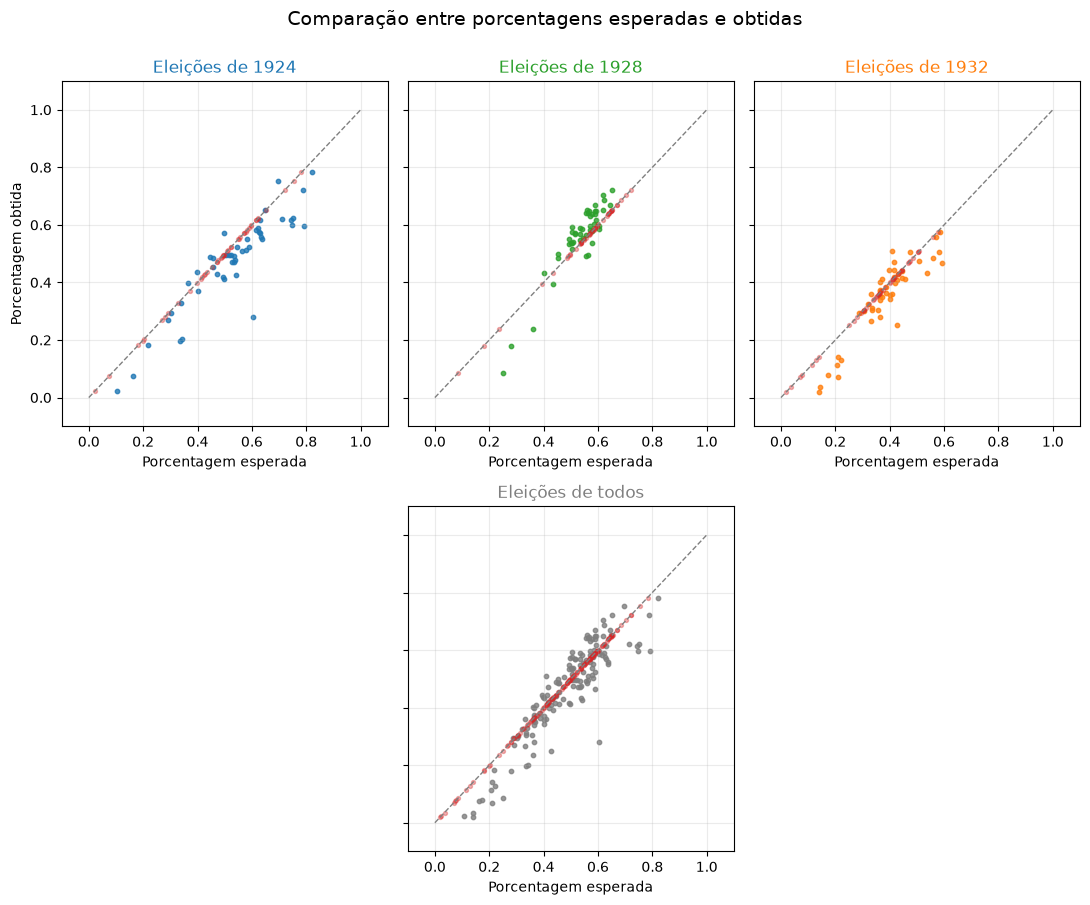

In [54]:
# Scatter plots comparativos entre porcentagem esperada e porcentagem obtida
fig, axes = plt.subplots(2, 3, figsize=(11, 9), sharey=True)
axes = axes.ravel()
colors = ["tab:blue", "tab:green", "tab:orange", "tab:cyan", "tab:gray"]

comparative_data = [
    ("1924", x_1924, y_1924),
    ("1928", x_1928, y_1928),
    ("1932", x_1932, y_1932),
    ("1936", x_1936, y_1936),
    ("todos", x, y),
]

for ax, (year, expected, actual), color in zip(axes, comparative_data, colors):
    ax.scatter(expected, actual, s=10, alpha=0.8, color=color)
    ax.scatter(actual, actual, s=8, color='tab:red', alpha=0.35, label='Real')
    # min_val = min(float(expected.min()), float(actual.min()))
    # max_val = max(float(expected.max()), float(actual.max()))
    # pad = max(0.05, (max_val - min_val) * 0.15)
    # line_min, line_max = max(0.0, min_val - pad), min(1.0, max_val + pad)
    line_min, line_max = 0, 1
    ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"Eleições de {year}", color=color)
    ax.set_xlabel("Porcentagem esperada")
    if ax is axes[0]:
        ax.set_ylabel("Porcentagem obtida")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.25)

axes[-1].set_visible(False)
axes[-3].set_visible(False)
fig.suptitle("Comparação entre porcentagens esperadas e obtidas", fontsize=14, y=1)
fig.tight_layout()
plt.show()

In [55]:
# --- 2. Treinamento do Modelo de Regressao com SVM ---
pipeline_svm_linear: Pipeline = Pipeline([
    ('svm', SVR(kernel='linear', C=10, gamma='scale')) # Médias: [0.8322, 0.7217]
])

# pipeline_svm_linear: Pipeline = Pipeline([
#     ('svm', SVR(kernel='rbf', C=1000, gamma=0.01)) # Médias: [0.8407, 0.7211]
# ])

# pipeline_svm_linear: Pipeline = Pipeline([
#     # ('scaler', StandardScaler()),
#     ('svm', SVR(kernel='rbf', C=100, gamma=0.01)) # Médias: [0.8463, 0.7188]
# ])

# pipeline_svm_linear: Pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svm', SVR(kernel='rbf', C=1, gamma=1))
# ])

MAE do SVR linear: 0.0499
RMSE do SVR linear: 0.0609
R2 do SVR linear: 0.7341
R2 em cada fold: [0.79777513 0.5536511  0.79889089 0.78554486 0.67244019]
Media: 0.7217
Desvio-padrão: 0.0964



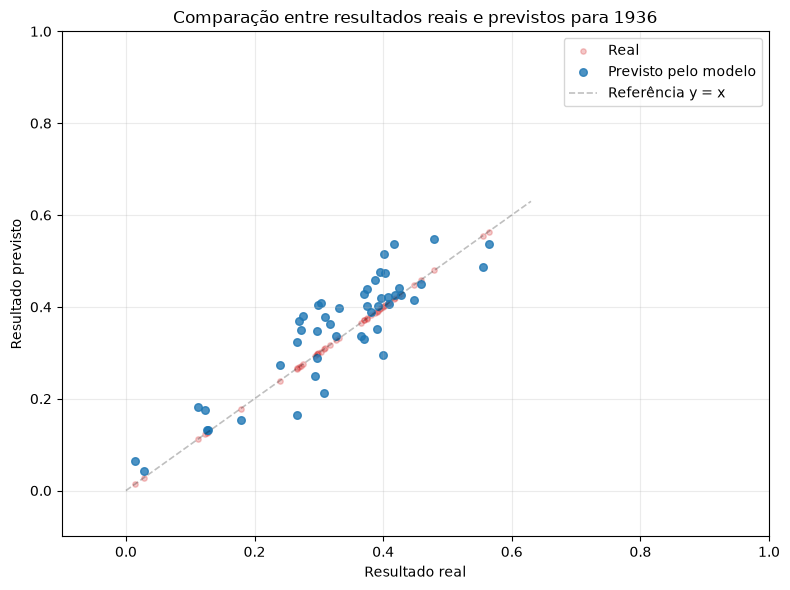

In [56]:
pipeline_svm_linear.fit(x, y)

# Previsão de resultados de eleições com amostras e resultados já conhecidos
y_pred: ndarray[tuple[int], dtype[np.float64]] = pipeline_svm_linear.predict(x_1936)

# Metricas apropriadas para um alvo continuo
mae_linear: float = mean_absolute_error(y_1936, y_pred)
rmse_linear: float = mean_squared_error(y_1936, y_pred) ** 0.5
r2_linear: float = r2_score(y_1936, y_pred)

# Validacao cruzada do SVR linear para analise do modelo em diferentes amostras
scores_linear: ndarray[tuple[int], dtype[np.floating]] = cross_val_score(pipeline_svm_linear, x_1936, y_1936, cv=5)

print(f"MAE do SVR linear: {mae_linear:.4f}")
print(f"RMSE do SVR linear: {rmse_linear:.4f}")
print(f"R2 do SVR linear: {r2_linear:.4f}")
print("R2 em cada fold:", scores_linear)
print(f"Media: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}\n")

# Scatter plot comparativo entre resultados reais e previstos pelo modelo para 1936
plt.figure(figsize=(8, 6))
plt.scatter(y_1936, y_1936, s=15, color='tab:red', alpha=0.25, label='Real')
plt.scatter(y_1936, y_pred, s=30, color='tab:blue', alpha=0.8, label='Previsto pelo modelo')

min_val: float = min(float(y_1936.min()), float(y_pred.min()))
max_val: float = max(float(y_1936.max()), float(y_pred.max()))
margin: float = max(0.05, (max_val - min_val) * 0.12)
line_min, line_max = max(0.0, min_val - margin), min(1.0, max_val + margin)
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--', color='black', linewidth=1.2, label='Referência y = x', alpha=0.25)

plt.title('Comparação entre resultados reais e previstos para 1936')
plt.xlabel('Resultado real')
plt.ylabel('Resultado previsto')
plt.xlim(-0.1, 1.0)
plt.ylim(-0.1, 1.0)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

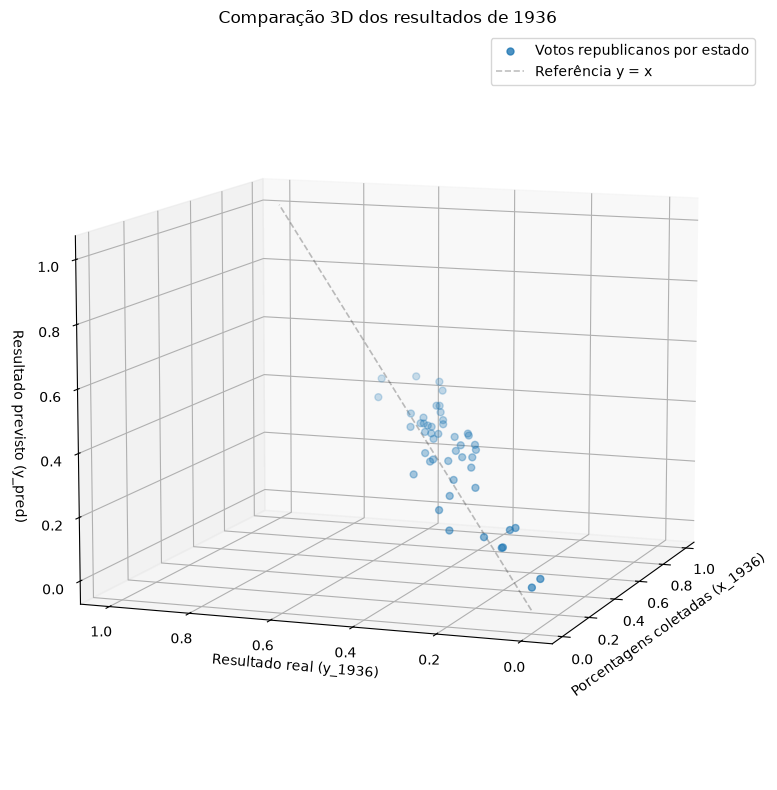

In [57]:
# Plot 3D dos valores esperados, reais e previstos
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x_1936_3d = np.asarray(x_1936).ravel()
y_1936_3d = np.asarray(y_1936).ravel()
y_pred_3d = np.asarray(y_pred).ravel()

ax.scatter(
    x_1936_3d,
    y_1936_3d,
    y_pred_3d,
    s=25,
    alpha=0.8,
    color="tab:blue",
    label="Votos republicanos por estado",
)

plt.plot([0, 1], [0, 1], [0, 1], linestyle='--', color='black', linewidth=1.2, label='Referência y = x', alpha=0.25)

ax.view_init(elev=10, azim=200, roll=0)

ax.set_title("Comparação 3D dos resultados de 1936")
ax.set_xlabel("Porcentagens coletadas (x_1936)")
ax.set_ylabel("Resultado real (y_1936)")
ax.set_zlabel("Resultado previsto (y_pred)")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

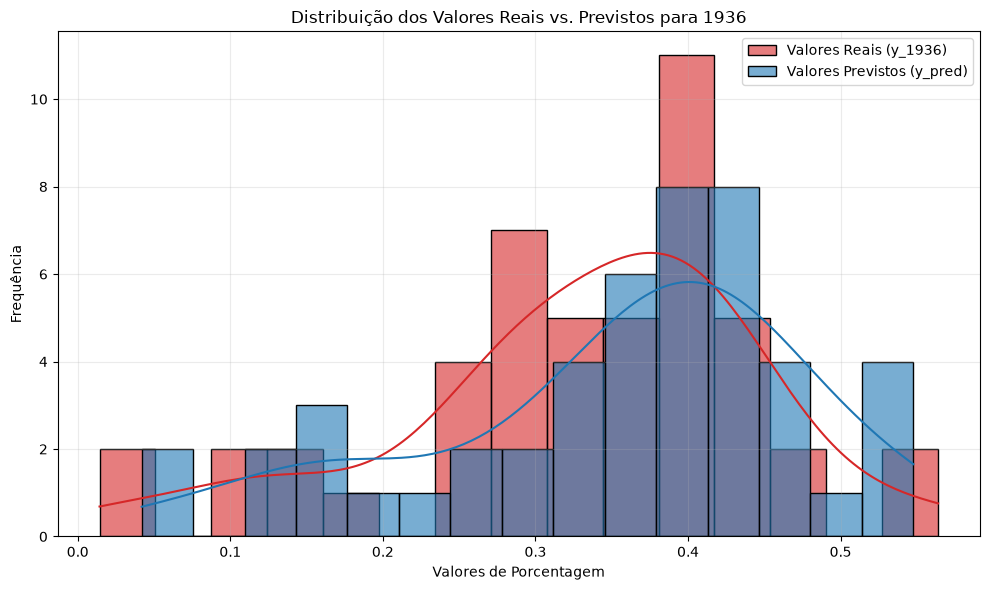

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(y_1936, color='tab:red', label='Valores Reais (y_1936)', kde=True, alpha=0.6, bins=15)
sns.histplot(y_pred, color='tab:blue', label='Valores Previstos (y_pred)', kde=True, alpha=0.6, bins=15)
plt.title('Distribuição dos Valores Reais vs. Previstos para 1936')
plt.xlabel('Valores de Porcentagem')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [62]:
actual_prop_1936 = DataFrame([y_1936, results_1936[results_1936.columns[2]]]).transpose()
df_results = DataFrame(
    {
      'state': StatesEnum._member_names_,
      'predicted_winner': ['Republicano' if rep > (1 - rep) else 'Democrata' for rep in y_pred],
      'actual_winner': ['Republicano' if rep > dem else 'Democrata' for (rep, dem) in actual_prop_1936.values],
    })

df_results['correct'] = df_results.iloc[:, 1].eq(df_results.iloc[:, 2])
df_results['predicted'] = y_pred * 100
df_results['actual'] = actual_prop_1936[actual_prop_1936.columns[0]]
df_results['diff'] = (y_pred * 100) - y_1936

guesses = df_results['correct'].value_counts()

print(guesses)
print(f"\nAcertos:\n{100 - (guesses.values[1] / guesses.values[0]) * 100:.2f}%")

correlation_1936 = np.corrcoef(y_1936, y_pred)[0, 1]
print(f"Correlação entre valores reais e previstos para 1936:\n{correlation_1936 * 100:.2f}%")

df_results.head(48)

correct
True     44
False     4
Name: count, dtype: int64

Acertos:
90.91%
Correlação entre valores reais e previstos para 1936:
89.24%


,state,predicted_winner,actual_winner,correct,predicted,actual,diff
0,ALABAMA,Democrata,Democrata,True,13.111142,0.1282,12.982942
1,ARIZONA,Democrata,Democrata,True,36.841244,0.2693,36.571944
2,ARKANSAS,Democrata,Democrata,True,15.381877,0.1786,15.203277
3,CALIFORNIA,Democrata,Democrata,True,36.233621,0.3170,35.916621
4,COLORADO,Democrata,Democrata,True,42.807246,0.3709,42.436346
5,CONNECTICUT,Democrata,Democrata,True,47.453387,0.4035,47.049887
6,DELAWARE,Democrata,Democrata,True,41.580519,0.4485,41.132019
7,FLORIDA,Democrata,Democrata,True,27.328418,0.2390,27.089418
8,GEORGIA,Democrata,Democrata,True,13.249966,0.1260,13.123966
9,IDAHO,Democrata,Democrata,True,39.765667,0.3319,39.433767


* **Pipeline de Aprendizado de Máquina (`StandardScaler` + `SVR` Linear):** Estrutura um `Pipeline` contendo a padronização z-score dos atributos e um classificador Support Vector Machine (`SVR`) com kernel linear (`kernel='linear'`, `C=10`), projetado para encontrar o hiperplano ótimo de separação de classes.
* **Validação Cruzada K-Fold (`cross_val_score`):** Submete o pipeline do SVM linear a uma validação cruzada com 5 dobras (`cv=5`) para mensurar a estabilidade, a média de acurácia e o desvio-padrão do classificador em diferentes partições dos dados históricos.